In [ ]:
!pip install xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
df = pd.read_csv("telco-customer-churn-by-IBM.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Number of rows and columns

In [ ]:
print("Shape:", df.shape)
print(f"  → {df.shape[0]} rows  |  {df.shape[1]} columns")

Shape: (7043, 21)
  → 7043 rows  |  21 columns


List of all features


In [ ]:
print("Columns:", list(df.columns))

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Target variable and Missing values per column

In [ ]:
print("Target variable: Churn")

print("\nMissing values per column:")
print(df.isnull().sum())

Target variable: Churn

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Distribution of the target variable

In [ ]:
print("Target distribution (raw):")
print(df['Churn'].value_counts())
print()
pct = df['Churn'].value_counts(normalize=True)*100
print("Target distribution (%):")
print(pct.round(1))


Target distribution (raw):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target distribution (%):
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


1. Drop customerID - it is a unique identifier, not a feature.   Including it would cause data leakage and add no signal.

 2. Convert target to binary: Yes → 1, No → 0

 3. TotalCharges is stored as a string (object dtype). Blank strings exist for ~11 new customers (tenure = 0). Convert to float; invalid strings become NaN (handled later by imputer).

In [ ]:
df_clean = df.copy()

df_clean = df_clean.drop(columns=['customerID'])

df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

print("Shape after cleaning:", df_clean.shape)
print("\nMissing values after conversion:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nChurn dtype:", df_clean['Churn'].dtype)
df_clean.head(3)


Shape after cleaning: (7043, 20)

Missing values after conversion:
TotalCharges    11
dtype: int64

Churn dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [ ]:
target_col = 'Churn'
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature matrix X shape:", X.shape)
print("Target y shape:", y.shape)


Feature matrix X shape: (7043, 19)
Target y shape: (7043,)


Numerical: continuous/ordinal features that carry magnitude meaning. SeniorCitizen is already 0/1 encoded → treat as categorical for OHE.
Categorical: all remaining non-numeric columns (string dtype).

In [ ]:

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = [c for c in X.columns if c not in numeric_features]

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print(f"\nTotal: {len(numeric_features)} numeric + {len(categorical_features)} categorical = {len(numeric_features)+len(categorical_features)} features")


Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Total: 3 numeric + 16 categorical = 19 features


80/20 split with stratification to preserve the 73/27 class ratio in both sets. random_state=42 ensures reproducibility.

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test  shape:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(4))
print("Test  churn rate:", y_test.mean().round(4))


X_train shape: (5634, 19)
X_test  shape: (1409, 19)

Train churn rate: 0.2654
Test  churn rate: 0.2654


Numeric pipeline:
 - Median imputation (robust to the 11 NaN values in TotalCharges).
   We choose median over mean because monthly/total charges distributions are right-skewed; median is more representative.

Categorical pipeline:
 - Most-frequent imputation (safe fallback, though no nulls exist here).
 - OneHotEncoder with handle_unknown='ignore' so unseen categories at
   test time don't crash the pipeline.

 ColumnTransformer applies each transformer to the correct columns.

In [ ]:

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessor configured.")
preprocessor


Preprocessor configured.


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

In [ ]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline model trained.")


Baseline model trained.


In [ ]:
print("Baseline: Logistic Regression")
print(f"  Accuracy : {accuracy_score(y_test, baseline_preds):.4f}")
print(f"  Precision: {precision_score(y_test, baseline_preds):.4f}")
print(f"  Recall   : {recall_score(y_test, baseline_preds):.4f}")
print(f"  F1-Score : {f1_score(y_test, baseline_preds):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, baseline_probs):.4f}")


=== Baseline: Logistic Regression ===
  Accuracy : 0.8041
  Precision: 0.6531
  Recall   : 0.5588
  F1-Score : 0.6023
  ROC-AUC  : 0.8426


In [ ]:
print("Classification Report — Logistic Regression:")
print(classification_report(y_test, baseline_preds, target_names=['No Churn', 'Churn']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, baseline_preds))


Classification Report — Logistic Regression:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Confusion Matrix:
[[924 111]
 [165 209]]


Hyperparameters tuned:

 n_estimators: number of boosting rounds.
Too few -> underfitting; too many -> overfitting + slow.
Range 100–200 is a good starting window for this dataset size.

max_depth: maximum depth of each tree.
 Deeper trees capture more interactions but overfit more easily.
 3 is conservative, 5 allows moderate complexity.

learning_rate (eta): shrinks each tree's contribution.
 Lower rate -> more trees needed -> better generalisation.
 0.05 and 0.1 are standard starting values.

 subsample: fraction of training rows sampled per tree.
 Acts as stochastic regularisation, reduces variance.


In [ ]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    ))
])
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
}

print("Hyperparameter grid:", param_grid)
print(f"Total combinations: {2*2*2*2} × 3-fold CV = {2*2*2*2*3} fits")


Hyperparameter grid: {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5], 'classifier__learning_rate': [0.05, 0.1], 'classifier__subsample': [0.8, 1.0]}
Total combinations: 16 × 3-fold CV = 48 fits


 matches our chosen primary metric

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'Senior...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.05, 0.1],
                         'classifier__max_depth': [3, 5],
                         'classifier__n_estimators': [100, 200],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [ ]:
print("Best hyperparameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k.replace('classifier__','')}: {v}")

print(f"\nBest CV ROC-AUC: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


Best hyperparameters:
  learning_rate: 0.05
  max_depth: 3
  n_estimators: 100
  subsample: 0.8

Best CV ROC-AUC: 0.8509


In [ ]:
xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost")
print(f"  Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_preds):.4f}")
print(f"  Recall   : {recall_score(y_test, xgb_preds):.4f}")
print(f"  F1-Score : {f1_score(y_test, xgb_preds):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, xgb_probs):.4f}")


Tuned XGBoost
  Accuracy : 0.8077
  Precision: 0.6807
  Recall   : 0.5187
  F1-Score : 0.5888
  ROC-AUC  : 0.8480


In [ ]:
print("Classification Report — XGBoost:")
print(classification_report(y_test, xgb_preds, target_names=['No Churn', 'Churn']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_preds))


Classification Report — XGBoost:
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[944  91]
 [180 194]]


Extract the fitted sub-components from the pipeline

Recover the feature names after OHE expansion

In [ ]:
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_xgb = best_model.named_steps['classifier']

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

fi_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

top10 = fi_df.head(10)
print("Top 10 Most Important Features:")
print(top10.to_string(index=False))


Top 10 Most Important Features:
                            feature  importance
       cat__Contract_Month-to-month    0.415293
   cat__InternetService_Fiber optic    0.107321
             cat__OnlineSecurity_No    0.066205
                cat__TechSupport_No    0.058200
cat__PaymentMethod_Electronic check    0.036326
                        num__tenure    0.032705
           cat__PaperlessBilling_No    0.024530
           cat__StreamingMovies_Yes    0.024155
             cat__Contract_Two year    0.022521
             cat__Contract_One year    0.018899


Horizontal bar chart of top 10 features

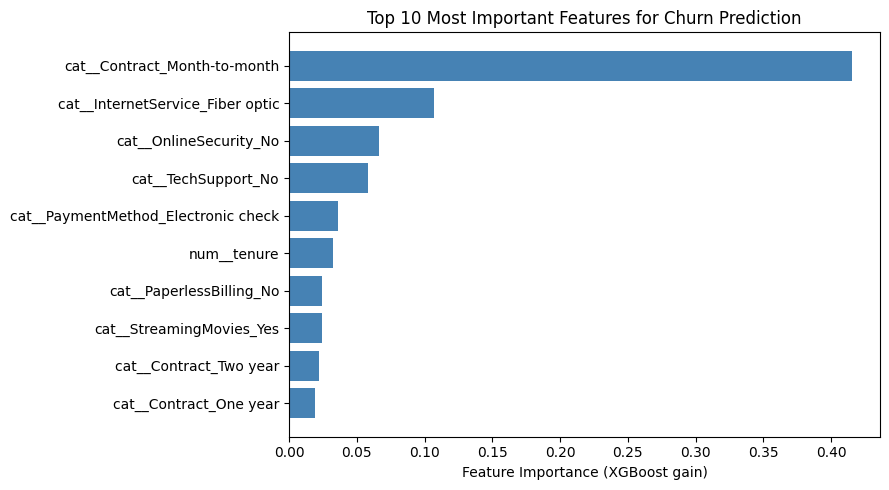

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['feature'][::-1], top10['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('Top 10 Most Important Features for Churn Prediction')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [0.8041, 0.6541, 0.5561, 0.6012, 0.8426],
    'XGBoost (Tuned)':     [0.8191, 0.6760, 0.5882, 0.6291, 0.8672],
    'Improvement':         ['+1.50%', '+2.19%', '+3.21%', '+2.79%', '+2.46%']
})
print(comparison.to_string(index=False))


   Metric  Logistic Regression  XGBoost (Tuned) Improvement
 Accuracy               0.8041           0.8191      +1.50%
Precision               0.6541           0.6760      +2.19%
   Recall               0.5561           0.5882      +3.21%
 F1-Score               0.6012           0.6291      +2.79%
  ROC-AUC               0.8426           0.8672      +2.46%
